# Forward Model Results Evaluation
Loads, filters, compares, and visualises Ultranest fitting results for a chosen target.

## 0 · Configuration

In [20]:
# ── Target selection ──────────────────────────────────────────────────────────
TARGET = "lsr"   # "lsr" | "bri"

# ── Model names to include (None = all found on disk) ─────────────────────────
MODEL_NAMES_LSR = [

    # 4-component models
    "quiescent_background_three_spots",
    "loose_ring_quiescent_background_two_spots",
    "two_rings_two_spots",
    # "two_rings_one_spot_quiescent_background",
    "four_spots",
    "three_spots_one_ring",
   

    # 5-component models
    "four_spots_one_ring",
    "three_spots_two_rings",
    "three_spots_one_ring_quiescent_background",
    # "two_spots_two_rings_quiescent_background",
    "four_spots_quiescent_background",
    "five_spots",


    # 6-component models
    "four_spots_one_ring_quiescent_background",
    "four_spots_two_rings",
    # "three_spots_two_rings_quiescent_background",
    "six_spots",
    "five_spots_quiescent_background",
    "five_spots_ring",



    # 7-component check
    # "six_spots_ring",


    # broadening check
    # "five_spots_ring_4broaden",
    # "five_spots_ring_16broaden",
    ]

MODEL_NAMES_BRI = [
    "ring_only",
    "spot_only",
    "two_spots",
    "loose_ring_one_spot"]

MODEL_NAMES = MODEL_NAMES_LSR if TARGET == "lsr" else MODEL_NAMES_BRI

# ── Paths ─────────────────────────────────────────────────────────────────────
RESULTS_DIR    = f"results_{TARGET}"
LSR_DATA_PATH  = "/home/ilin/Documents/2025_10_pydoppler/scripts/lsr1835bins20/"
SPECTRA_CSV    = f"results_lsr/lsr_norm_spectra.csv"

# ── Plot settings ─────────────────────────────────────────────────────────────
N_TOP_MODELS   = 6      # models shown in spectra / sphere panels
ALPHA_FACTOR   = 0.0004 # opacity scaling for sphere visualisation
SPECTRA_OFFSET = 1.7    # vertical offset between phase rows in spectra plot

## 1 · Imports & utilities

In [21]:
import json
import os
import re
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [22]:
def group_params(res: dict) -> dict:
    """Partition a flat parameter dict into spots / rings / background groups.

    Returns
    -------
    dict with keys 'spots', 'rings', 'background', each a list of param-name lists.
    """
    res_set = set(res)

    # ── Spots ─────────────────────────────────────────────────────────────────
    spot_indices = sorted({
        int(m.group(1))
        for p in res
        for m in [re.fullmatch(r'lat(\d+)', p)]
        if m
    })
    spots = [
        [name for name in [f'lat{i}', f'lon{i}', f'width{i}', f'amplon{i}'] if name in res_set]
        for i in spot_indices
    ]

    # ── Rings ─────────────────────────────────────────────────────────────────
    ring_indices = sorted({
        int(m.group(1))
        for p in res
        for m in [re.fullmatch(r'ringwidth(\d+)', p)]
        if m
    })
    shared = [p for p in ['i_mag', 'ringlat', 'alpha0'] if p in res_set]

    rings = []
    if len(ring_indices) == 1:
        per_ring = sorted(
            [p for p in res_set if re.fullmatch(r'ringwidth(\d*)', p) or re.fullmatch(r'amplring(\d*)', p)],
            key=lambda x: (0 if x.startswith('ringwidth') else 1, x),
        )
        shared.insert(2, per_ring[0])   # ringwidth
        shared.append(per_ring[1])      # amplring
        rings.append(shared)
    else:
        for i in ring_indices:
            per_ring = sorted(
                [name for name in [f'ringwidth{i}', f'amplring{i}'] if name in res_set],
                key=lambda x: (0 if x.startswith('ringwidth') else 1, x),
            )
            shared_copy = shared.copy()
            shared_copy.insert(2, per_ring[0])
            shared_copy.append(per_ring[1])
            rings.append(shared_copy)

    # ── Background ────────────────────────────────────────────────────────────
    background = [['amplback']] if 'amplback' in res_set else []

    return {'spots': spots, 'rings': rings, 'background': background}


def convert_params(res: dict) -> dict:
    """Convert stored (transformed) parameter values back to physical angles.

    Stored as sin/cos → returned in radians.
    """
    res = res.copy()
    arcsin_params  = ['i_mag', 'lat1', 'lat2', 'lat3', 'lat4', 'lat5']
    arccos_params  = ['ringlat', 'trueringlat']
    truelat_params = ['truelat', 'truelat2']

    for p in arcsin_params:
        if p in res:
            res[p] = np.arcsin(res[p])
    if 'truei_mag' in res:
        res['truei_mag'] = np.arcsin(res['truei_mag']) + np.pi / 2
    for p in arccos_params:
        if p in res:
            res[p] = np.arccos(res[p])
    for p in truelat_params:
        if p in res:
            res[p] = np.arcsin(res[p]) + np.pi / 2
    return res


def median_params(post_summary: pd.DataFrame) -> dict:
    """Extract median parameter values from a post_summary DataFrame."""
    res = post_summary.filter(like='median').iloc[0].to_dict()
    return {k.replace('_median', ''): v for k, v in res.items()}

## 2 · Load target-specific factory & models

In [23]:
if TARGET == "lsr":
    from funcs.lsr import register_lsr_models as register_models
    from funcs.lsr import setup_lsr_factory as setup_factory
    from funcs.lsr import NAME_LSR as target_name
    from funcs.lsr import get_lsr_data
    from funcs.lsr import GRIDSIZE_LSR
    from funcs.lsr import PROT_LSR
    # Same grid resolution as run_forward_model_lsr.py, so the visualised
    # spot/ring geometry matches the one the fit actually integrated over.
    FACTORY_KWARGS = {"gridsize": GRIDSIZE_LSR}
elif TARGET == "bri":
    from funcs.bri import register_bri_models as register_models
    from funcs.bri import setup_bri_factory as setup_factory
    from funcs.bri import NAME_BRI as target_name
    FACTORY_KWARGS = {}
else:
    raise ValueError(f"Unknown target: {TARGET!r}")

## 3 · Load results from disk

In [24]:
EXCLUDED_SUBDIRS = {"corner_plots", "chains"}
EXCLUDED_FOLDERS = {"ring_one_spot", "ring_two_spots", "results_lsr/two_spots_ultranest"}

def _is_valid_folder(path: str) -> bool:
    basename = os.path.basename(path)
    if any(excl in path for excl in EXCLUDED_SUBDIRS):
        return False
    if any(excl in basename for excl in EXCLUDED_FOLDERS) and "loose_ring" not in basename:
        return False
    return True


def _latest_run_folder(folder: str) -> str:
    """Return the folder holding the latest run's chains/info.

    Some models were fit once and store chains/info/results directly in
    `folder`; others were fit repeatedly and store each attempt under a
    `runN` subfolder. Prefer the latest `runN` subfolder when present,
    otherwise fall back to `folder` itself.
    """
    run_folders = [
        f.path for f in os.scandir(folder)
        if f.is_dir() and f.name.startswith("run") and f.name[3:].isdigit()
    ]
    if not run_folders:
        return folder
    return sorted(run_folders, key=lambda x: int(x.split("run")[-1]))[-1]


def load_results(results_dir: str) -> list[dict]:
    """Scan results_dir and load chains, post summary and Ultranest output."""
    folders = [
        f.path for f in os.scandir(results_dir)
        if f.is_dir() and _is_valid_folder(f.path)
    ]

    data = []
    for folder in folders:
        run_folder = _latest_run_folder(folder)
        chains_file          = os.path.join(run_folder, "chains", "equal_weighted_post.txt")
        post_summary_file    = os.path.join(run_folder, "info", "post_summary.csv")
        results_ultranest_file = os.path.join(run_folder, "info", "results.json")

        with open(results_ultranest_file) as f:
            results_ultranest = json.load(f)

        data.append({
            "folder":            folder,
            "post_summary":      pd.read_csv(post_summary_file),
            "chains":            pd.read_csv(chains_file, sep=r"\s+"),
            "results_ultranest": results_ultranest,
        })
    return data


def filter_by_model_names(data: list[dict], model_names: list[str]) -> list[dict]:
    """Keep only entries whose folder matches one of the requested model names."""
    return [
        d for d in data
        if any(name + "_ultranest" in os.path.basename(d["folder"]) for name in model_names)
    ]


# ── Run ───────────────────────────────────────────────────────────────────────
data = load_results(RESULTS_DIR)
data = filter_by_model_names(data, MODEL_NAMES)

print(f"Loaded {len(data)} model result(s):")
for d in data:
    print(" ", os.path.basename(d["folder"]))

Loaded 15 model result(s):
  five_spots_ring_ultranest
  quiescent_background_three_spots_ultranest
  three_spots_two_rings_ultranest
  four_spots_one_ring_ultranest
  four_spots_quiescent_background_ultranest
  two_rings_two_spots_ultranest
  five_spots_quiescent_background_ultranest
  five_spots_ultranest
  six_spots_ultranest
  three_spots_one_ring_ultranest
  four_spots_ultranest
  loose_ring_quiescent_background_two_spots_ultranest
  four_spots_two_rings_ultranest
  four_spots_one_ring_quiescent_background_ultranest
  three_spots_one_ring_quiescent_background_ultranest


## 4 · Build name mapping (folder → readable label)

In [25]:
modelfactory, vdmids, alphas = setup_factory(obj_only=True, **FACTORY_KWARGS)
model_list, model_name_list  = register_models(modelfactory)

map_names: dict[str, str] = {
    f"{mod.__name__}_ultranest": name
    for mod, name in zip(model_list, model_name_list)
}

# Extend to every completed fit on disk, not just the 32 base structures --
# register_models already made all of them resolve via get_model() (see
# funcs.lsr.register_variants_from_results), so give them a matching pretty
# label too, current or historical broaden/inclination alike, instead of
# falling back to the raw folder name.
if TARGET == "lsr":
    from funcs.lsr import variant_display_name
    for entry in os.scandir(RESULTS_DIR):
        if entry.is_dir() and entry.name.endswith("_ultranest"):
            name  = entry.name[: -len("_ultranest")]
            label = variant_display_name(name)
            if label is not None:
                map_names[entry.name] = label

def display_name(d: dict) -> str:
    return map_names.get(os.path.basename(d["folder"]), os.path.basename(d["folder"]))

## 5 · Model comparison — logZ table & bar chart

In [26]:
# ── Observed data (needed to turn max log-likelihood into chi^2) ──────────────
if TARGET == "lsr":
    observed_data, observed_data_err = get_lsr_data(LSR_DATA_PATH, vdmids)
else:
    observed_data = observed_data_err = None
    print("chi^2/dof needs a get_bri_data() data loader wired up for BRI -- skipping.")

Found 20 files in /home/ilin/Documents/2025_10_pydoppler/scripts/lsr1835bins20/
Number of files: 20
Reading error values from: results_lsr/subtracted_spectra_errvals.txt


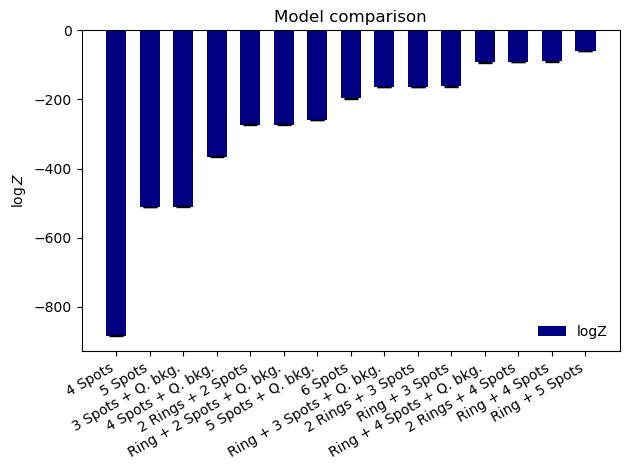

In [27]:
logzs    = [d["results_ultranest"]["logz"]    for d in data]
logzerrs = [d["results_ultranest"]["logzerr"] for d in data]
names    = [display_name(d)                   for d in data]

# chi^2 and degrees of freedom, from the maximum-likelihood point already
# stored in results.json -- no need to re-evaluate any model. The UltraNest
# likelihood (SpectralModelFactory.create_ultranest_likelihood) is
#   logL = -0.5 * chi^2 + logf,   logf = -0.5 * sum(log(2*pi*sigma^2))
# so chi^2 = -2*(logL - logf); logf depends only on the (shared) data errors.
if observed_data_err is not None:
    ndata    = observed_data.size
    logf     = -0.5 * np.sum(np.log(2 * np.pi * observed_data_err.ravel() ** 2))
    maxlogls = [d["results_ultranest"]["maximum_likelihood"]["logl"] for d in data]
    nparams  = [len(d["results_ultranest"]["paramnames"])            for d in data]
    chi2s    = [-2 * (ll - logf) for ll in maxlogls]
    dofs     = [ndata - k        for k in nparams]
    redchi2s = [c / dof          for c, dof in zip(chi2s, dofs)]
else:
    chi2s = dofs = redchi2s = [np.nan] * len(data)

# Sort by ascending logZ for the bar chart
order          = np.argsort(logzs)
logzs_sorted   = [logzs[i]    for i in order]
errs_sorted    = [logzerrs[i] for i in order]
names_sorted   = [names[i]    for i in order]
chi2_sorted    = [chi2s[i]    for i in order]
dof_sorted     = [dofs[i]     for i in order]
redchi2_sorted = [redchi2s[i] for i in order]

fig, ax = plt.subplots()
ax.bar(np.arange(len(logzs_sorted)), logzs_sorted, yerr=errs_sorted,
       width=0.6, capsize=5, facecolor="navy", label="logZ")
ax.set_ylabel(r"$\log Z$")
ax.set_xticks(np.arange(len(logzs_sorted)), names_sorted, rotation=30, ha="right")
ax.legend(frameon=False)
plt.title("Model comparison")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model_comparison_logz.png", bbox_inches="tight")
plt.show()

In [28]:
# ── Export CSV + LaTeX ────────────────────────────────────────────────────────
results_table = (
    pd.DataFrame({
        "Model":    names_sorted,
        "logZ":     logzs_sorted,
        "logZerr":  errs_sorted,
        "chi2":     chi2_sorted,
        "dof":      dof_sorted,
        "chi2/dof": redchi2_sorted,
    })
    .sort_values("logZ", ascending=False)
)

# combine logZ and its uncertainty into one "value $\pm$ error" column,
# sorted numerically above while logZ was still a plain float
results_table["logZ"] = [
    f"{z:.1f} $\\pm$ {e:.1f}"
    for z, e in zip(results_table["logZ"], results_table["logZerr"])
]
results_table = results_table.drop(columns="logZerr")
results_table["chi2"]     = results_table["chi2"].map("{:.1f}".format)
results_table["chi2/dof"] = results_table["chi2/dof"].map("{:.2f}".format)

csv_path = f"{RESULTS_DIR}/model_comparison_table_{TARGET}.csv"
results_table.to_csv(csv_path, index=False)

latex_table = (
    results_table
    .to_latex(index=False, column_format="lcccc", escape=False,
              caption=f"Model comparison results for {target_name}.",
              label=f"tab:model_comparison_{TARGET}")
    .replace("chi2/dof",    r"$\chi^2/\mathrm{dof}$")
    .replace("chi2",        r"$\chi^2$")
    .replace("logZ",        r"$\log Z$")
    .replace(r"\toprule",   r"\hline\hline")
    .replace(r"\midrule",   r"\hline")
    .replace(r"\bottomrule",r"\hline")
)

tex_path = f"{RESULTS_DIR}/model_comparison_table_{TARGET}.tex"
with open(tex_path, "w") as f:
    f.write(latex_table)

print(latex_table)

\begin{table}
\caption{Model comparison results for LSR J1835.}
\label{tab:model_comparison_lsr}
\begin{tabular}{lcccc}
\hline\hline
Model & $\log Z$ & $\chi^2$ & dof & $\chi^2/\mathrm{dof}$ \\
\hline
Ring + 5 Spots & -59.5 $\pm$ 0.7 & 3914.3 & 975 & 4.01 \\
Ring + 4 Spots & -89.9 $\pm$ 1.0 & 3992.7 & 979 & 4.08 \\
2 Rings + 4 Spots & -91.4 $\pm$ 0.6 & 3976.6 & 977 & 4.07 \\
Ring + 4 Spots + Q. bkg. & -93.0 $\pm$ 1.0 & 3989.3 & 978 & 4.08 \\
Ring + 3 Spots & -162.4 $\pm$ 0.9 & 4156.3 & 983 & 4.23 \\
2 Rings + 3 Spots & -163.8 $\pm$ 0.9 & 4144.7 & 981 & 4.22 \\
Ring + 3 Spots + Q. bkg. & -164.7 $\pm$ 0.7 & 4156.9 & 982 & 4.23 \\
6 Spots & -196.7 $\pm$ 0.8 & 4171.9 & 976 & 4.27 \\
5 Spots + Q. bkg. & -259.8 $\pm$ 0.8 & 4330.3 & 979 & 4.42 \\
Ring + 2 Spots + Q. bkg. & -273.0 $\pm$ 1.0 & 4383.8 & 986 & 4.45 \\
2 Rings + 2 Spots & -273.2 $\pm$ 0.8 & 4382.7 & 985 & 4.45 \\
4 Spots + Q. bkg. & -365.4 $\pm$ 0.6 & 4564.6 & 983 & 4.64 \\
3 Spots + Q. bkg. & -509.9 $\pm$ 0.5 & 4875.2 & 987 & 4.9

## 6 · Sort data by logZ (best first)

In [29]:
data_sorted = sorted(data, key=lambda d: d["results_ultranest"]["logz"], reverse=True)

## 7 · Best-fit spectra (top N models)

In [30]:
# ── Reload factory with full pipeline (obj_only=False) ────────────────────────
modelfactory_full, vmids, alphas = setup_factory(obj_only=False, **FACTORY_KWARGS)
model_list, model_name_list      = register_models(modelfactory_full)

observed_data, observed_data_err = get_lsr_data(LSR_DATA_PATH, vmids)

# ── Observed spectra CSV (for raw phase coverage) ─────────────────────────────
df_spectra = (
    pd.read_csv(SPECTRA_CSV)
    .rename(columns={"Unnamed: 0": "lambda"})
)
df_spectra.columns = ["lambda"] + [float(x) % 1 for x in df_spectra.columns[1:]]
df_spectra["lambda"] = (df_spectra["lambda"] - 6562.8) / 6562.8 * 3e5  # → km/s

Found 20 files in /home/ilin/Documents/2025_10_pydoppler/scripts/lsr1835bins20/
Number of files: 20
Reading error values from: results_lsr/subtracted_spectra_errvals.txt


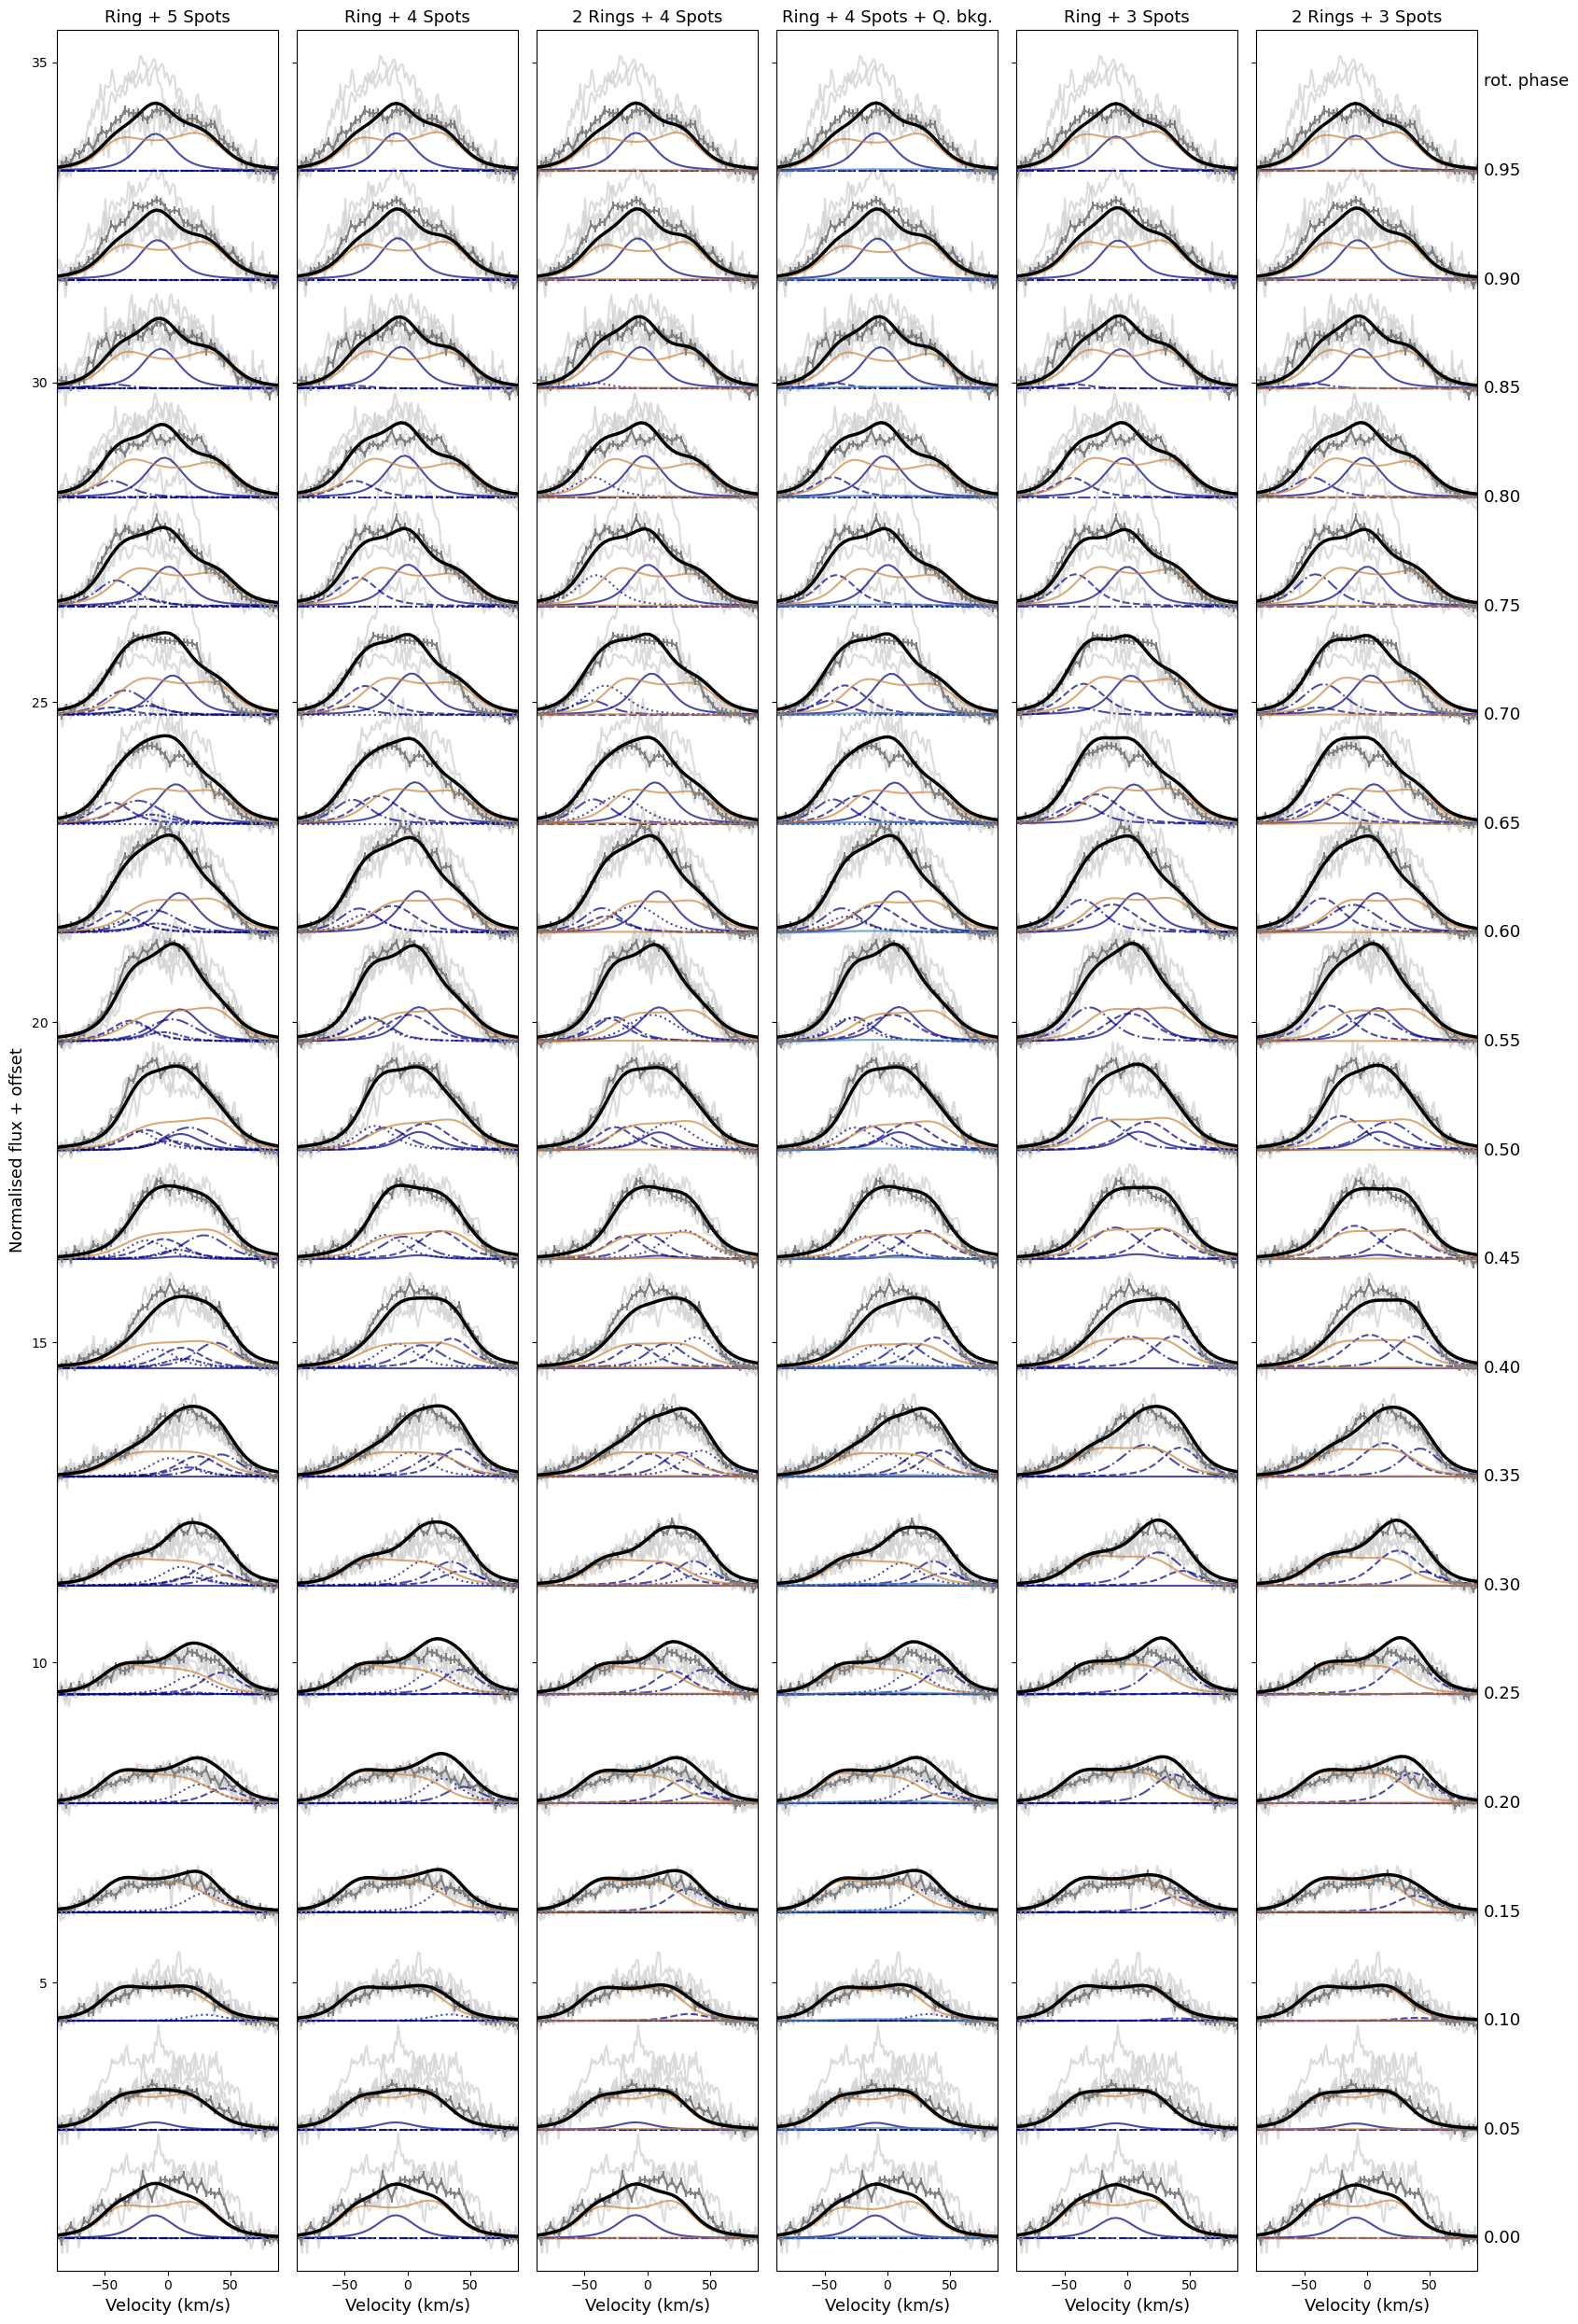

In [31]:
# set fontsize of ticklabels to 12
plt.rcParamsDefault.update({'xtick.labelsize': 13, 'ytick.labelsize': 13})

top_data = data_sorted[:N_TOP_MODELS]
if N_TOP_MODELS == 1:
    offset_size = 1
else:
    offset_size = -1
fig, axs = plt.subplots(nrows=1, ncols=len(top_data),
                        figsize=(3 * len(top_data) -1 , 25), sharey=True)
if type(axs) != np.ndarray:
    axs = np.ndarray([axs])

for nump, dat in enumerate(top_data):
    modelname = "_".join(os.path.basename(dat["folder"]).split("_")[:-1])
    
    suffix    = "_show" if TARGET == "bri" else ""
    mmodel    = modelfactory_full.get_model(modelname + suffix)
    # The factory this model actually runs against -- for a non-default
    # broaden/inclination variant (current or historical), this is a
    # dedicated factory built at that configuration, not modelfactory_full
    # itself (see funcs.lsr.register_variants_from_results / get_factory).
    # Building components straight off modelfactory_full would silently
    # ignore that and always draw at its own default broaden/inclination.
    factory   = modelfactory_full.get_factory(modelname + suffix)

    res    = convert_params(median_params(dat["post_summary"]))
    groups = group_params(res)

    ax     = axs[nump]

    specsum      = np.zeros((len(alphas), len(vmids)))
    n_components = 0
    linestyles   = itertools.cycle(["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (3, 5, 1, 5))])
    ringnum      = 0

    for group_name, param_groups in groups.items():
        for paramnames in param_groups:
            paramlist = [res[p] for p in paramnames]

            if group_name == "rings":
                if ringnum == 1:
                    paramlist[1] = -paramlist[1]
                obj = factory.ring(*paramlist)
                color, ls = "peru", "-"
                ringnum += 1
            elif group_name == "spots":
                obj = factory.spot(*paramlist)
                color, ls = "navy", next(linestyles)
            elif group_name == "background":
                obj = factory.background(*paramlist)
                color, ls = "steelblue", "-"
            else:
                raise ValueError(f"Unknown group: {group_name!r}")

            for i, spectrum in enumerate(obj):
                ax.plot(vmids, spectrum + i * SPECTRA_OFFSET,
                        color=color, alpha=0.7, linestyle=ls)
            specsum      += obj
            n_components += 1

    # Total model spectrum
    for i, subspec in enumerate(specsum):
        ax.plot(vmids, subspec + i * SPECTRA_OFFSET - n_components + 1,
                color="black", lw=2.5, zorder=10)

    # Observed data
    for i, spectrum in enumerate(observed_data):
        ax.errorbar(vmids, spectrum + i * SPECTRA_OFFSET,
                    yerr=observed_data_err[i], color="grey", alpha=1)

    # Individual spectra from CSV binned by phase (light grey)
    for i, alpha in enumerate(alphas):
        ph        = np.abs(np.array(df_spectra.columns[1:]) % 1 - 1 + alpha / (2 * np.pi))
        col_names = df_spectra.columns[1:][(ph < 0.05) & (ph >= 0.0)]
        for spectrum in df_spectra[col_names].T.values:
            ax.plot(df_spectra["lambda"], spectrum + i * SPECTRA_OFFSET,
                    color="lightgrey", alpha=0.8, zorder=0)

    ax.set_title(display_name(dat), fontsize=13)
    ax.set_xlabel("Velocity (km/s)",fontsize=13)
    ax.set_xlim(vmids[0], vmids[-1])
    ax.set_ylim(0.5, 35.5)

axs[0].set_ylabel("Normalised flux + offset", fontsize=13)

# Phase labels on the right of the last panel
for i, alpha in enumerate(alphas):
    phase_val = (alpha % (2 * np.pi)) / (2 * np.pi)
    axs[-1].text(vmids[-1] + 5, i * SPECTRA_OFFSET + 1,
                 f"{phase_val:.2f}", va="center", ha="left", fontsize=13)

axs[-1].text(vmids[-1] + 5, len(alphas) * SPECTRA_OFFSET + 0.71,
             "rot. phase", va="center", ha="left", fontsize=13)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/best_fit_spectra_{TARGET}.png",
            bbox_inches="tight", facecolor="white", dpi=200)
plt.show()

## 7b · χ² residual diagnostics (top N models)

Per-phase and per-velocity-bin χ² for each of the top `N_TOP_MODELS` models,
overplotted -- summing the pixel-wise residuals over the other axis. Flags
whether a model's misfit is spread evenly or concentrated in a few phases /
velocities, and lets that be compared across models directly.

Ring + 5 Spots                 total chi2 (median params) =   3923.2
Ring + 4 Spots                 total chi2 (median params) =   4178.8
2 Rings + 4 Spots              total chi2 (median params) =   3996.6
Ring + 4 Spots + Q. bkg.       total chi2 (median params) =   3995.4
Ring + 3 Spots                 total chi2 (median params) =   4195.2
2 Rings + 3 Spots              total chi2 (median params) =   4172.6


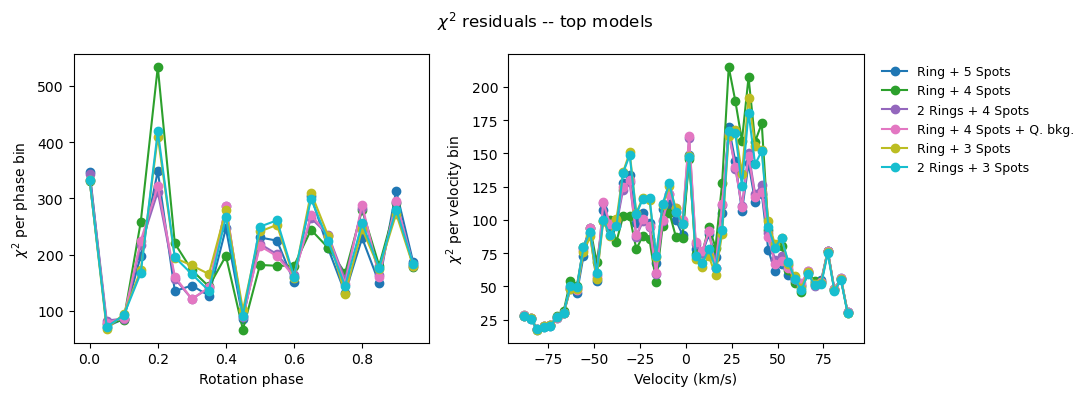

In [32]:
# ── χ² per phase bin / per velocity bin (top N models overplotted) ────────────
colors     = plt.cm.tab10(np.linspace(0, 1, len(top_data)))
phase_vals = (alphas % (2 * np.pi)) / (2 * np.pi)
chi2_maps  = []   # full (phase x velocity) map per model, reused by the heat map below

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(11, 4))

for dat, color in zip(top_data, colors):
    modelname = "_".join(os.path.basename(dat["folder"]).split("_")[:-1])
    suffix    = "_show" if TARGET == "bri" else ""
    # See the spectra plot above: this model's own factory, not
    # modelfactory_full, so a non-default broaden/inclination variant is
    # actually evaluated at its own configuration.
    factory   = modelfactory_full.get_factory(modelname + suffix)

    res    = convert_params(median_params(dat["post_summary"]))
    groups = group_params(res)

    specsum      = np.zeros((len(alphas), len(vmids)))
    n_components = 0
    ringnum      = 0
    for group_name, param_groups in groups.items():
        for paramnames in param_groups:
            paramlist = [res[p] for p in paramnames]
            if group_name == "rings":
                if ringnum == 1:
                    paramlist[1] = -paramlist[1]
                obj = factory.ring(*paramlist)
                ringnum += 1
            elif group_name == "spots":
                obj = factory.spot(*paramlist)
            elif group_name == "background":
                obj = factory.background(*paramlist)
            else:
                raise ValueError(f"Unknown group: {group_name!r}")
            specsum      += obj
            n_components += 1

    # Each component sits on its own continuum baseline of ~1, so summing
    # N of them raises the local continuum to ~N -- the same correction
    # modelfactory.combine() applies (sum(components) - (len(components)-1))
    # and the same one the spectra plot above applies via its offset term.
    # Skipping this inflates chi2 by a systematic offset of (n_components-1)
    # against errors of order 0.05-0.07, not a real misfit.
    model_spectra = specsum - (n_components - 1)

    # Per-pixel chi^2 from the posterior-median model above -- not the
    # maximum-likelihood point used for the chi^2/dof column in section 5's
    # table, so totals here can differ slightly from that one.
    chi2_pixel     = ((observed_data - model_spectra) / observed_data_err) ** 2
    chi2_per_phase = chi2_pixel.sum(axis=1)   # sum over velocity bins -> one value per phase
    chi2_per_vbin  = chi2_pixel.sum(axis=0)   # sum over phases -> one value per velocity bin
    chi2_maps.append(chi2_pixel)

    label = display_name(dat)
    ax1.plot(phase_vals, chi2_per_phase, "o-", color=color, label=label)
    ax2.plot(vmids, chi2_per_vbin, "o-", color=color, label=label)
    print(f"{label:30} total chi2 (median params) = {chi2_pixel.sum():8.1f}")

ax1.set_xlabel("Rotation phase")
ax1.set_ylabel(r"$\chi^2$ per phase bin")
ax2.set_xlabel("Velocity (km/s)")
ax2.set_ylabel(r"$\chi^2$ per velocity bin")
ax2.legend(frameon=False, fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1))

fig.suptitle(r"$\chi^2$ residuals -- top models")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/chi2_per_bin_{TARGET}.png",
            bbox_inches="tight", dpi=150)
plt.show()

## 7c · χ² heat map (phase × velocity, top N models)

Where the per-pixel χ² clusters, one panel per model, sharing a colour
scale so the panels are directly comparable.

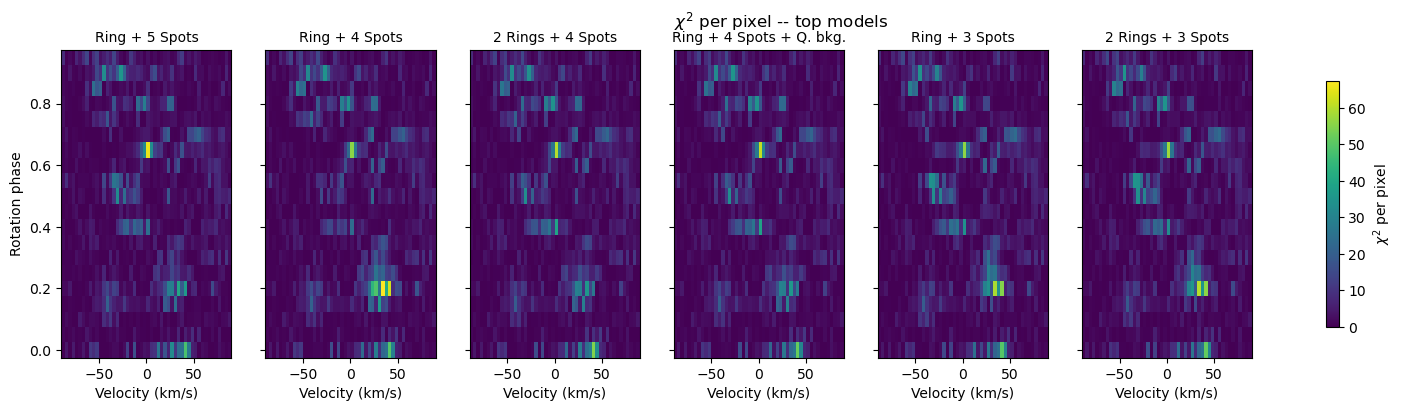

In [33]:
# ── χ² heat map (phase × velocity) for each of the top N models ───────────────
fig, axs = plt.subplots(nrows=1, ncols=len(top_data),
                         figsize=(3.2 * len(top_data), 4), sharey=True)
if not isinstance(axs, np.ndarray):
    axs = np.array([axs])

# shared colour scale across panels, robust to a handful of extreme pixels
# (a single badly-mismatched line core can otherwise wash out everything else)
vmax = np.percentile(np.concatenate([m.ravel() for m in chi2_maps]), 99.99)

for ax, dat, chi2_pixel in zip(axs, top_data, chi2_maps):
    im = ax.pcolormesh(vmids, phase_vals, chi2_pixel,
                        cmap="viridis", vmin=0, vmax=vmax, shading="nearest")
    ax.set_title(display_name(dat), fontsize=10)
    ax.set_xlabel("Velocity (km/s)")

axs[0].set_ylabel("Rotation phase")
fig.colorbar(im, ax=axs, label=r"$\chi^2$ per pixel", shrink=0.8)
fig.suptitle(r"$\chi^2$ per pixel -- top models")
plt.savefig(f"{RESULTS_DIR}/chi2_heatmap_{TARGET}.png",
            bbox_inches="tight", dpi=150)
plt.show()

## 8 · Sphere visualisations (top N models)

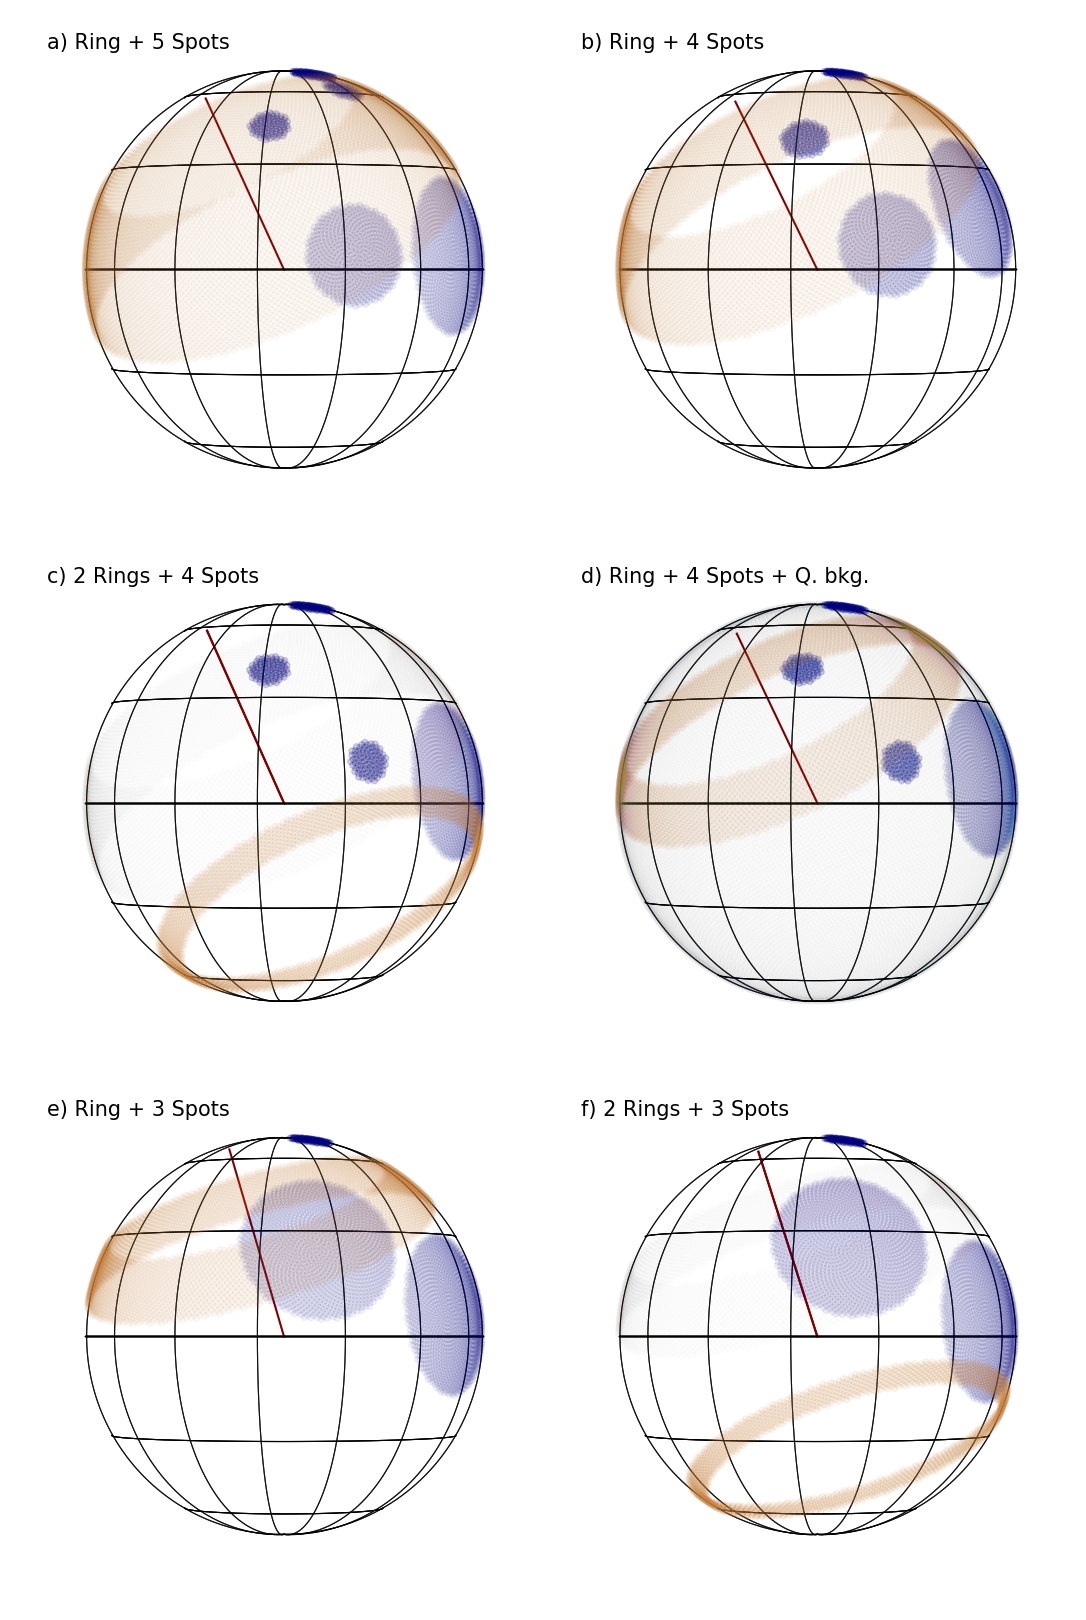

In [34]:
modelfactory_obj, vdmids, alphas = setup_factory(obj_only=True, **FACTORY_KWARGS)
model_list, model_name_list      = register_models(modelfactory_obj)

n_rows   = 3 if TARGET == "lsr" else 2
VIEW_AZ  = -np.pi / 4

fig = plt.figure(figsize=(16, 16), frameon=False)
spec = fig.add_gridspec(ncols=2, nrows=n_rows)
axs  = []
for row in range(n_rows):
    for col in range(2):
        ax = fig.add_subplot(spec[row, col], projection="3d")
        ax.set_axis_off()
        ax.set_box_aspect([1, 1, 1], zoom=1.5)
        axs.append(ax)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=-0.5, hspace=0)

panel_labels = [f"{c})" for c in "abcdefghij"]

for nump, dat in enumerate(data_sorted[:N_TOP_MODELS]):
    modelname = "_".join(os.path.basename(dat["folder"]).split("_")[:-1])
    suffix    = "_show" if TARGET == "bri" else ""
    mmodel    = modelfactory_obj.get_model(modelname + suffix)
    # This model's own factory, not modelfactory_obj -- see the spectra plot
    # above (a non-default broaden/inclination variant otherwise silently
    # renders at modelfactory_obj's own default configuration).
    factory   = modelfactory_obj.get_factory(modelname + suffix)

    res    = convert_params(median_params(dat["post_summary"]))
    groups = group_params(res)
    ax     = axs[nump]
    ringnum = 0

    for group_name, param_groups in groups.items():
        for paramnames in param_groups:
            paramlist = [res[p] for p in paramnames]
            factor    = 15000  # normalisation constant

            if group_name == "rings":
                if ringnum == 1:
                    paramlist[1] = -paramlist[1]
                obj   = factory.ring(*paramlist)
                a     = paramlist[-1]
                alpha_vis = np.sqrt(a * (factor / obj.x.shape[0]) * ALPHA_FACTOR * 2)
                obj.plot_ring(ax, VIEW_AZ, s=20, c="peru", ring_alpha=alpha_vis)
                ringnum += 1
            elif group_name == "spots":
                obj   = factory.spot(*paramlist)
                a     = paramlist[-1]
                alpha_vis = np.sqrt(a * (factor / obj.x.shape[0]) * ALPHA_FACTOR)
                obj.plot_spot(ax, VIEW_AZ, s=20, c="navy", ring_alpha=alpha_vis)
            elif group_name == "background":
                obj   = factory.background(*paramlist)
                a     = paramlist[-1]
                alpha_vis = np.sqrt(a * (factor / obj.x.shape[0]) * ALPHA_FACTOR)
                obj.plot_ring(ax, VIEW_AZ, s=20, c="steelblue", ring_alpha=alpha_vis, axis=False)
            else:
                raise ValueError(f"Unknown group: {group_name!r}")

        obj.plot_layout_sphere(ax)
        obj.plot_lat_lon_grid(ax, num_lat=5, num_lon=14, offset_lon=0.02)

    ax.text(0.95, 0.95, 13,
            f"{panel_labels[nump]} {display_name(dat)}",
            fontsize=15, ha="left", va="top", transform=ax.transAxes)

for ax in axs:
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = True
        pane.set_facecolor("white")

plt.savefig(f"{RESULTS_DIR}/best_fit_spheres_{TARGET}.png",
            bbox_inches="tight", facecolor="white", dpi=300)
plt.show()

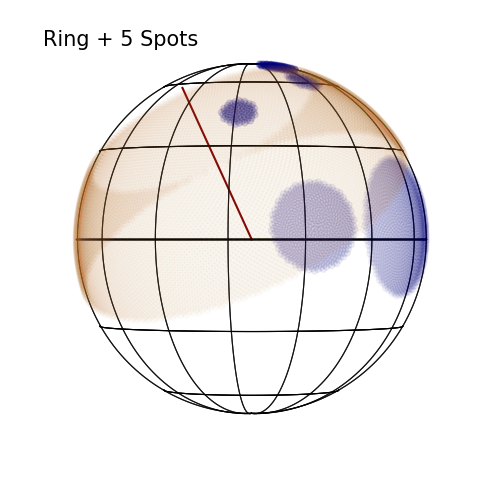

In [35]:
# ── Single-sphere view: best model ────────────────────────────────────────────
dat = data_sorted[0]

fig = plt.figure(figsize=(5,5), frameon=False)
ax  = fig.add_subplot(111, projection="3d")
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1], zoom=1.5)

modelname = "_".join(os.path.basename(dat["folder"]).split("_")[:-1])
suffix    = "_show" if TARGET == "bri" else ""
mmodel    = modelfactory_obj.get_model(modelname + suffix)
# This model's own factory, not modelfactory_obj -- see the spectra plot
# above (a non-default broaden/inclination variant otherwise silently
# renders at modelfactory_obj's own default configuration).
factory   = modelfactory_obj.get_factory(modelname + suffix)

res    = convert_params(median_params(dat["post_summary"]))
groups = group_params(res)
ringnum = 0

for group_name, param_groups in groups.items():
    for paramnames in param_groups:
        paramlist = [res[p] for p in paramnames]
        factor    = 12000

        if group_name == "rings":
            if ringnum == 1:
                paramlist[1] = -paramlist[1]
            obj       = factory.ring(*paramlist)
            alpha_vis = np.sqrt(paramlist[-1] * (factor / obj.x.shape[0]) * ALPHA_FACTOR * 2)
            obj.plot_ring(ax, VIEW_AZ, s=20, c="peru", ring_alpha=alpha_vis)
            ringnum += 1
        elif group_name == "spots":
            obj       = factory.spot(*paramlist)
            alpha_vis = np.sqrt(paramlist[-1] * (factor / obj.x.shape[0]) * ALPHA_FACTOR)
            obj.plot_spot(ax, VIEW_AZ, s=20, c="navy", ring_alpha=alpha_vis)
        elif group_name == "background":
            obj       = factory.background(*paramlist)
            alpha_vis = np.sqrt(paramlist[-1] * (factor / obj.x.shape[0]) * ALPHA_FACTOR)
            obj.plot_ring(ax, VIEW_AZ, s=20, c="steelblue", ring_alpha=alpha_vis, axis=False)

    obj.plot_layout_sphere(ax)
    obj.plot_lat_lon_grid(ax, num_lat=5, num_lon=14, offset_lon=0.02)

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = True
    pane.set_facecolor("white")

ax.text(0.95, 0.95, 13, display_name(dat), fontsize=15,
        ha="left", va="top", transform=ax.transAxes)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/best_model_sphere_{TARGET}.png", bbox_inches="tight", facecolor="white", dpi=300)
plt.show()

## 8b · Highest-latitude spot: Does it fit the ECME phase?

Assume peak of H alpha emission is related to ECME, too.

For each of the top `N_TOP_MODELS` models, find the spot closest to the
pole and the rotational phase at which it faces the observer most
directly.

Then compare that spot's quadrature phase (90 deg / 0.25 phase units
before facing the observer) to the phase where the *observed* Halpha
emission actually peaks, converts the (circular) phase offset to a
temporal offset using the rotation period, and reports the range of that
offset across the top models

In [39]:
# ── Highest-latitude spot: phase of peak visibility ↔ longitude ───────────────
def highest_latitude_spot_phase(dat, n_alpha=361):
    """For the highest-latitude spot in a model, return its longitude and
    the rotational phase at which it faces the observer most directly.

    "Most directly" is found by sweeping alpha finely and taking the phase
    where the spot's raw (un-normalised) line signature -- from the model's
    own visibility/foreshortening geometry, AuroralRing.get_spot_flux_
    numerically -- is strongest, rather than re-deriving the phase<->
    longitude relationship analytically: that mapping also depends on the
    (tilted) rotation axis set by the fitted obliquity, not lon alone.

    Returns a dict with the spot's index, latitude/longitude (deg, same
    convention as model_table.py: lat 90=pole/0=equator, lon in [0, 360)),
    and its peak-visibility phase in [0, 1).

    Parameters
    ----------
    dat : dict
        A single model's result dict, as returned by load_results().

    n_alpha : int, optional
        Number of phase samples to sweep over when finding the peak.

    Returns
    -------
    dict
        A dict with keys "model", "spot", "lat_deg", "lon_deg", and "phase" (peak visibility).
    """
    res = convert_params(median_params(dat["post_summary"]))
    spot_indices = sorted({
        int(m.group(1)) for p in res for m in [re.fullmatch(r"lat(\d+)", p)] if m
    })
    if not spot_indices:
        raise ValueError(f"No spots found in {display_name(dat)!r}")

    # highest latitude = smallest colatitude-from-pole (convert_params's
    # arcsin convention: 0 = pole, pi/2 = equator)
    i_top = min(spot_indices, key=lambda i: res[f"lat{i}"])

    lat, lon, width, ampl = (res[f"lat{i_top}"], res[f"lon{i_top}"],
                              res[f"width{i_top}"], res[f"amplon{i_top}"])

    # This model's own factory, not modelfactory_obj -- a non-default
    # broaden/inclination variant changes i_rot, which the visibility sweep
    # below depends on directly (see the spectra plot cell for the same
    # point re: broaden).
    modelname = "_".join(os.path.basename(dat["folder"]).split("_")[:-1])
    suffix    = "_show" if TARGET == "bri" else ""
    factory   = modelfactory_obj.get_factory(modelname + suffix)


    # get line emission time series for the highest latitude spot 
    # at a fine grid of rotational phases
    ring        = factory.spot(lat, lon, width, ampl)
    fine_alphas = np.linspace(0, 2 * np.pi, n_alpha)
    flux        = ring.get_spot_flux_numerically(fine_alphas, foreshortening=True)
    flux        = np.asarray(flux)
    visibility  = np.abs(flux).sum(axis=1)
    alpha_peak  = fine_alphas[np.argmax(visibility)]
    phase_peak  = (alpha_peak % (2 * np.pi)) / (2 * np.pi)

    return {
        "model":   display_name(dat),
        "spot":    i_top,
        "lat_deg": 90 - np.degrees(lat),
        "lon_deg": np.degrees(lon) % 360,
        "phase":   phase_peak,
    }


# Phase of peak total Halpha emission in the observed data (all omponents that might involve)
line_excess_per_phase = (observed_data - 1).sum(axis=1)
peak_phase_obs         = phase_vals[np.argmax(line_excess_per_phase)]
print(f"Total Halpha emission (observed) peaks at phase {peak_phase_obs:.3f}\n")

t_peak_mjd = 0.835 + 55766 # from Hallinan+2015 MJD

# For each of the top N models: highest-latitude spot's quadrature phase
# (0.25 phase units, i.e. 90 deg, before it faces the observer) vs. the
# observed Halpha peak, as a temporal offset via the rotation period.
offsets_days = []
for dat in top_data:
    result = highest_latitude_spot_phase(dat)
    delta_phase_quadrature = peak_phase_obs - (result["phase"] - 0.25)
    offset_days = delta_phase_quadrature * PROT_LSR
    offsets_days.append(offset_days)
    print(f"{result['model']:26} spot {result['spot']} "
          f"(lat={result['lat_deg']:5.1f} deg, lon={result['lon_deg']:6.1f} deg): "
          f"visible at phase {result['phase']:.3f}, quadrature {delta_phase_quadrature:+.3f} "
          f"phase units before the Halpha peak ({offset_days * 24:+.2f} h)")

print(f"\nTemporal offset (quadrature -> observed Halpha peak) across the "
      f"top {len(top_data)} models: "
      f"{min(offsets_days):+.3f} to {max(offsets_days):+.3f} days "
      f"({min(offsets_days) * 24:+.2f} to {max(offsets_days) * 24:+.2f} h)")

Total Halpha emission (observed) peaks at phase 0.600

Ring + 5 Spots             spot 1 (lat= 76.9 deg, lon=  85.9 deg): visible at phase 0.761, quadrature +0.089 phase units before the Halpha peak (+0.25 h)
Ring + 4 Spots             spot 1 (lat= 78.0 deg, lon=  87.0 deg): visible at phase 0.758, quadrature +0.092 phase units before the Halpha peak (+0.26 h)
2 Rings + 4 Spots          spot 1 (lat= 78.0 deg, lon=  87.0 deg): visible at phase 0.758, quadrature +0.092 phase units before the Halpha peak (+0.26 h)
Ring + 4 Spots + Q. bkg.   spot 1 (lat= 78.0 deg, lon=  87.0 deg): visible at phase 0.758, quadrature +0.092 phase units before the Halpha peak (+0.26 h)
Ring + 3 Spots             spot 1 (lat= 78.7 deg, lon=  88.9 deg): visible at phase 0.753, quadrature +0.097 phase units before the Halpha peak (+0.28 h)
2 Rings + 3 Spots          spot 1 (lat= 78.3 deg, lon=  88.3 deg): visible at phase 0.756, quadrature +0.094 phase units before the Halpha peak (+0.27 h)

Temporal offset (qua

## 8c · Best two models: spheres + residual maps (2×2)

Side by side spot/ring geometry for the top two models, with each one's
χ² residual heat map directly below it -- so a difference in geometry
between the two best fits can be read against where it actually costs
each model in the data.

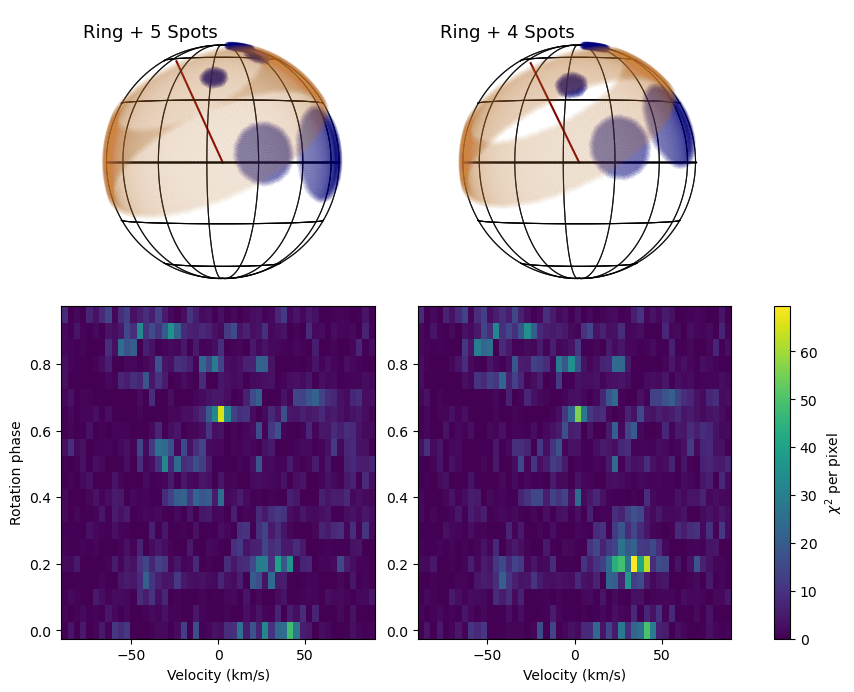

In [37]:
# ── Best two models: spheres (top) + residual maps (bottom) ───────────────────
top2 = data_sorted[:2]

# facecolor="white" (not frameon=False, used for the sphere-only figures
# above): frameon=False skips drawing the figure's background patch at all,
# so it renders transparent -- fine when the whole figure is 3D panes
# forced white, but here the 2D residual row's own background shows through
# too, appearing dark in a dark-themed viewer until saved with facecolor set.
fig  = plt.figure(figsize=(9.4, 8.3), facecolor="white")
# a dedicated narrow column for the colorbar, rather than fig.colorbar(ax=...)
# stealing space from resid_axes alone: that shrinks only the row it's given,
# leaving the sphere row above at its original width -- the two rows'
# columns no longer line up.
#
# hspace is negative, not just 0: a 3D Axes with a fixed box_aspect reserves
# a chunk of its cell as invisible margin around the actual sphere (for the
# view angle/rotation), so even with zero cell-to-cell gap there's still a
# visible band of white below the sphere. Overlapping the cells eats into
# that reserved margin, not the visible sphere -- checked empirically that
# -0.18 lands just short of the sphere's own drawn content.
spec = fig.add_gridspec(ncols=3, nrows=2, height_ratios=[1, 1],
                         width_ratios=[1, 1, 0.05], hspace=-0.08)

sphere_axes = [fig.add_subplot(spec[0, col], projection="3d") for col in range(2)]
resid_axes  = [fig.add_subplot(spec[1, col])                  for col in range(2)]
cbar_ax     = fig.add_subplot(spec[1, 2])

factor = 12000  # same normalisation constant as the single-sphere view above
for dat, ax in zip(top2, sphere_axes):
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1], zoom=1.5)

    # This model's own factory, not modelfactory_obj -- see the spectra plot
    # cell above (a non-default broaden/inclination variant otherwise
    # silently renders at modelfactory_obj's own default configuration).
    modelname = "_".join(os.path.basename(dat["folder"]).split("_")[:-1])
    suffix    = "_show" if TARGET == "bri" else ""
    factory   = modelfactory_obj.get_factory(modelname + suffix)

    res     = convert_params(median_params(dat["post_summary"]))
    groups  = group_params(res)
    ringnum = 0

    for group_name, param_groups in groups.items():
        for paramnames in param_groups:
            paramlist = [res[p] for p in paramnames]

            if group_name == "rings":
                if ringnum == 1:
                    paramlist[1] = -paramlist[1]
                obj       = factory.ring(*paramlist)
                alpha_vis = np.sqrt(paramlist[-1] * (factor / obj.x.shape[0]) * ALPHA_FACTOR * 2)
                obj.plot_ring(ax, VIEW_AZ, s=20, c="peru", ring_alpha=alpha_vis)
                ringnum += 1
            elif group_name == "spots":
                obj       = factory.spot(*paramlist)
                alpha_vis = np.sqrt(paramlist[-1] * (factor / obj.x.shape[0]) * ALPHA_FACTOR)
                obj.plot_spot(ax, VIEW_AZ, s=20, c="navy", ring_alpha=alpha_vis)
            elif group_name == "background":
                obj       = factory.background(*paramlist)
                alpha_vis = np.sqrt(paramlist[-1] * (factor / obj.x.shape[0]) * ALPHA_FACTOR)
                obj.plot_ring(ax, VIEW_AZ, s=20, c="steelblue", ring_alpha=alpha_vis, axis=False)
            else:
                raise ValueError(f"Unknown group: {group_name!r}")

        obj.plot_layout_sphere(ax)
        obj.plot_lat_lon_grid(ax, num_lat=5, num_lon=14, offset_lon=0.02)

    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = True
        pane.set_facecolor("white")

    ax.text(0.95, 0.95, 13, display_name(dat), fontsize=13,
            ha="left", va="top", transform=ax.transAxes)

# Residual maps below, reusing the chi2 maps already computed in 7b for
# top_data (top_data[:2] == data_sorted[:2], same order) -- no need to
# re-evaluate either model.
resid_vmax = np.percentile(np.concatenate([chi2_maps[0].ravel(), chi2_maps[1].ravel()]), 99.99)
for col, (dat, ax) in enumerate(zip(top2, resid_axes)):
    ax.set_facecolor("white")
    im = ax.pcolormesh(vmids, phase_vals, chi2_maps[col],
                        cmap="viridis", vmin=0, vmax=resid_vmax, shading="nearest")
    ax.set_xlabel("Velocity (km/s)")
resid_axes[0].set_ylabel("Rotation phase")

fig.colorbar(im, cax=cbar_ax, label=r"$\chi^2$ per pixel")

plt.savefig(f"{RESULTS_DIR}/top2_spheres_and_residuals_{TARGET}.png",
            bbox_inches="tight", facecolor="white", dpi=300)
plt.show()

## 9 · `model_table.py` command for the best models

Prints a ready-to-run command line for `model_table.py`, one `modelname:"Label"`
argument per model, best `logZ` first (top `N_TOP_MODELS`).

In [38]:
specs = []
for dat in data_sorted[:3]:
    modelname = "_".join(os.path.basename(dat["folder"]).split("_")[:-1])
    specs.append(f'{modelname}:"{display_name(dat)}"')

cmd = "python 4_model_table.py \\\n    " + " \\\n    ".join(specs)
print(cmd)

python 4_model_table.py \
    five_spots_ring:"Ring + 5 Spots" \
    four_spots_one_ring:"Ring + 4 Spots" \
    four_spots_two_rings:"2 Rings + 4 Spots"
